In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_raw = pd.read_csv("D:\\ML&DL\\heart.csv")
data = data_raw.copy()

In [3]:
data.replace({"Age":0 , "RestingBP":0 , "Cholesterol":0 , "MaxHR":0 },np.nan , inplace=True)

In [4]:
data.isna().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [5]:
data_categorical = data.select_dtypes("object")
data_numerical = data.select_dtypes(["float64" , "int64"]).iloc[:,:-1]
y = data.iloc[:,-1].values

In [6]:
from sklearn.preprocessing import LabelEncoder
label_enc = LabelEncoder()

In [7]:
data_categorical = data_categorical.apply(label_enc.fit_transform)

In [8]:
data_categorical.nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

In [9]:
from sklearn.preprocessing import OneHotEncoder
ohe_enc = OneHotEncoder()

In [10]:
data_categorical_bin = data_categorical[["Sex","ExerciseAngina"]]

In [11]:
data_ohe = ohe_enc.fit_transform(data_categorical[["ChestPainType", "RestingECG" , "ST_Slope"]].values).toarray()

In [12]:
data_ohe.shape

(918, 10)

In [13]:
data = np.concatenate([data_numerical.values , data_categorical_bin.values , data_ohe], axis = 1)

In [14]:
pd.DataFrame(data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,40.0,140.0,289.0,0.0,172.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49.0,160.0,180.0,0.0,156.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37.0,130.0,283.0,0.0,98.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48.0,138.0,214.0,0.0,108.0,1.5,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54.0,150.0,195.0,0.0,122.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45.0,110.0,264.0,0.0,132.0,1.2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
914,68.0,144.0,193.0,1.0,141.0,3.4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
915,57.0,130.0,131.0,0.0,115.0,1.2,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
916,57.0,130.0,236.0,0.0,174.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [15]:
from sklearn.impute import KNNImputer

In [16]:
imputer = KNNImputer(n_neighbors=3)

In [17]:
data = imputer.fit_transform(data)

In [18]:

from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [20]:
X = data

In [21]:
from sklearn.neighbors import KNeighborsClassifier

GridSearchCV

In [33]:
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV , ShuffleSplit

In [34]:
knn = KNeighborsClassifier()
params = {
    'n_neighbors': [3,5,7,9],
    'p': [2,3,4,5],
    'weights': ['uniform' ,'distance']
    }
cv = ShuffleSplit(n_splits=5 , test_size=0.3 , random_state=444)
clf_report = GridSearchCV(knn , param_grid = params , scoring='accuracy' , cv =cv , verbose=10 , refit=True)

In [35]:
clf_report.fit(X,y)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5; 1/32] START n_neighbors=3, p=2, weights=uniform........................
[CV 1/5; 1/32] END n_neighbors=3, p=2, weights=uniform;, score=0.841 total time=   0.0s
[CV 2/5; 1/32] START n_neighbors=3, p=2, weights=uniform........................
[CV 2/5; 1/32] END n_neighbors=3, p=2, weights=uniform;, score=0.830 total time=   0.0s
[CV 3/5; 1/32] START n_neighbors=3, p=2, weights=uniform........................
[CV 3/5; 1/32] END n_neighbors=3, p=2, weights=uniform;, score=0.819 total time=   0.0s
[CV 4/5; 1/32] START n_neighbors=3, p=2, weights=uniform........................
[CV 4/5; 1/32] END n_neighbors=3, p=2, weights=uniform;, score=0.801 total time=   0.0s
[CV 5/5; 1/32] START n_neighbors=3, p=2, weights=uniform........................
[CV 5/5; 1/32] END n_neighbors=3, p=2, weights=uniform;, score=0.841 total time=   0.0s
[CV 1/5; 2/32] START n_neighbors=3, p=2, weights=distance.......................
[CV 1/5; 2/3

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [2, 3, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,10
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [36]:
clf_report.best_score_

0.8420289855072463

In [37]:
clf_report.best_estimator_

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,5
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
clf_report.best_params_

{'n_neighbors': 9, 'p': 5, 'weights': 'uniform'}

In [39]:
knn_final = KNeighborsClassifier(n_neighbors=9,p=2,weights='uniform')
knn_final.fit(X,y)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [40]:
y_pred = knn_final.predict(X)

In [41]:
accuracy_score(y,y_pred)

0.8747276688453159

Random serach CV

In [42]:
knn = KNeighborsClassifier()
params = {
    'n_neighbors': range(1,30,2),
    'p': range(2,10),
    'weights': ['uniform' ,'distance']
    }
cv = ShuffleSplit(n_splits=5 , test_size=0.3 , random_state=444)
clf_r = RandomizedSearchCV(knn , param_distributions= params , scoring='accuracy' , cv =cv , verbose=1 , refit=True , n_iter=20 ,return_train_score=True)

In [43]:
clf_r.fit(X,y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,KNeighborsClassifier()
,param_distributions,"{'n_neighbors': range(1, 30, 2), 'p': range(2, 10), 'weights': ['uniform', 'distance']}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [44]:
clf_r.best_params_

{'weights': 'distance', 'p': 6, 'n_neighbors': 29}

In [45]:
knn_final = KNeighborsClassifier(n_neighbors=25 , p=9 , weights='distance')
knn_final.fit(X,y)

,n_neighbors,25
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,9
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
y_pred = knn_final.predict(X)

In [47]:
accuracy_score(y,y_pred)

1.0

In [59]:
clf_r.best_score_

0.8521739130434783

In [60]:
from sklearn import metrics

In [61]:
print(metrics.classification_report(y,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       410
           1       1.00      1.00      1.00       508

    accuracy                           1.00       918
   macro avg       1.00      1.00      1.00       918
weighted avg       1.00      1.00      1.00       918



Overfiting &
Underfiting.  
when the train score is grater or better yhan the test score >>> overfit and the underfit is inverse of this.

In [65]:
clf_r.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_weights', 'param_p', 'param_n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score', 'split0_train_score', 'split1_train_score', 'split2_train_score', 'split3_train_score', 'split4_train_score', 'mean_train_score', 'std_train_score'])

In [66]:
test_scores = clf_r.cv_results_["mean_test_score"]
train_scores = clf_r.cv_results_["mean_train_score"]

In [67]:
train_test_distance = train_scores / test_scores

In [68]:
train_test_distance.argmin()

8

In [69]:
train_scores[0]

0.8576323987538942

In [70]:
test_scores[0]

0.8413043478260871

In [71]:
clf_r.cv_results_['params'][0]

{'weights': 'uniform', 'p': 8, 'n_neighbors': 21}

In [72]:
knn_final = KNeighborsClassifier(n_neighbors=19 , p=4 , weights='uniform')
knn_final.fit(X,y)
y_pred = knn_final.predict(X)
accuracy_score(y,y_pred)

0.8496732026143791

In [73]:
knn = KNeighborsClassifier()
k_values = range(1,65,2)
params = {
    'n_neighbors':k_values ,
    }
cv = ShuffleSplit(n_splits=5 , test_size=0.25 , random_state=567)
clf_r = GridSearchCV(knn , param_grid= params , scoring='accuracy' , cv =cv , verbose=1 ,return_train_score=True , refit=True)

In [74]:
clf_r.fit(X,y)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(1, 65, 2)}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,ShuffleSplit(...ain_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,61


In [75]:
clf_r.best_score_

0.8513043478260869

In [76]:
test_scores = clf_r.cv_results_["mean_test_score"]
train_scores = clf_r.cv_results_["mean_train_score"]

In [77]:
train_test_distance = train_scores / test_scores

In [78]:
test_scores.max()

0.8513043478260869

In [79]:
arg_min_distance = train_test_distance.argmin()

In [80]:
arg_min_distance

23

In [81]:
test_scores[23]

0.8504347826086956

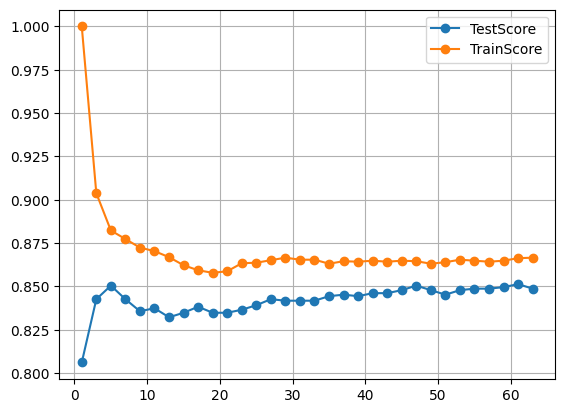

In [82]:
plt.plot(k_values , test_scores , '-o' , label ='TestScore')
plt.plot(k_values , train_scores , '-o' , label ='TrainScore')
plt.legend()
plt.grid(True)

In [83]:
knn_f = KNeighborsClassifier(n_neighbors=47)
knn_f.fit(X,y)
y_predict = knn_f.predict(X)
print(metrics.classification_report(y,y_predict))

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       410
           1       0.86      0.89      0.88       508

    accuracy                           0.86       918
   macro avg       0.86      0.86      0.86       918
weighted avg       0.86      0.86      0.86       918

